<a href="https://colab.research.google.com/github/arya2005-tech/CSL701-CS44-Machine-Learning-Lab/blob/main/Experiments/ML_Experiment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Arya Abhiram prabhudesai     
  Roll No: CS44

### Aim : To implement a Bagging (Bootstrap Aggregating) ensemble classifier from scratch using Python, apply it to the Pima Indians Diabetes Database, and evaluate its performance against a single base classifier (Decision Tree)**.


## Objectives

1. Understand Ensemble Learning Principles: Comprehend how combining the predictions of multiple diverse models reduces overall model variance.
2. Master Bootstrapping: Implement random resampling of data with replacement from scratch to generate distinct training subsets.
3. Develop a Voting System: Build an aggregation mechanism (Majority Voting) from scratch to consolidate predictions.
4. Learn Baseline Evaluation: Compare the performance of a high-variance, low-bias single decision tree against the more stable Bagging ensemble.
5. Analyze Performance Metrics: Calculate and visualize classification metrics, including a Confusion Matrix, Accuracy, Precision, Recall, and ROC-AUC curve.


Relevant Theory
Ensemble Methods and Bagging
Ensemble learning combines several individual classifiers (base learners) to produce a unified model that generalizes better than any single model on unseen data. Bootstrap Aggregating (Bagging) is a parallel ensemble method designed primarily to reduce variance. High-variance models—such as deep, fully-grown decision trees—are highly sensitive to small changes in their training datasets. Bagging addresses this by smoothing out individual model errors without increasing bias.

The two core components of Bagging are:

1. Bootstrapping (Sampling with Replacement): For a training set of size $N$, we generate $B$ new datasets of the same size $N$. Each instance is selected at random from the original dataset with replacement. This means a single instance can be selected multiple times, while on average, only about 63.2% of the unique training samples are captured in each bootstrap, leaving the rest as out-of-bag (OOB) samples.
2. Aggregating (Majority Voting): A separate base learner $h_b(x)$ is trained independently on each bootstrap sample. For classification, predictions are aggregated by passing a test sample to all $B$ models and taking a majority vote: $$\hat{G}{\text{bag}}(x) = \text{argmax}{k} \sum_{b=1}^{B} I(h_b(x) = k)$$

An alternative to standard Bagging is subagging (subsample aggregating), where smaller training subsets (often $N/2$) are drawn without replacement to reduce correlation and accelerate computation.

---
## Software Requirements

- **Language:** Python 3.x

- **Core Libraries:**
  - **NumPy** for matrix manipulation and custom bootstrapping operations.
  - **Pandas** for loading, indexing, and cleaning tabular data.
  - **Matplotlib / Seaborn** for exploratory scatter plots, bar charts, and performance visualization.
  - **Scikit-learn** for train-test splitting, training individual base decision trees, and comparison with built-in Bagging algorithms.

---

## Dataset Information

The experiment utilizes the **Pima Indians Diabetes Database** from the UCI Machine Learning Repository. The dataset contains medical details for 768 female Pima Indian patients living in Arizona, categorized as either diabetic or non-diabetic.

- **Total Instances:** 768

- **Features (8 predictor variables):**
  1. **`Pregnancies`**: Number of times pregnant.
  2. **`Glucose`**: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.
  3. **`BloodPressure`**: Diastolic blood pressure (mm Hg).
  4. **`SkinThickness`**: Triceps skin fold thickness (mm).
  5. **`Insulin`**: 2-Hour serum insulin ($\mu$U/ml).
  6. **`BMI`**: Body mass index (weight in kg/m$^2$).
  7. **`DiabetesPedigreeFunction`**: A function representing genetic predisposition.
  8. **`Age`**: Age of the subject in years.

- **Target Label (9th column):** **`Outcome`**
  - **0** represents non-diabetic.
  - **1** represents diabetic.

## Experimental Tasks

### Task 1: Environment Setup and Dataset Acquisition

Use dataset using the link  
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

**Goal:** Set up the workspace and load the data.

**Instructions:**

1. Import the necessary modules: **`numpy`**, **`pandas`**, **`matplotlib.pyplot`**, and **`sklearn`**.

2. Load the file **`pima-indians-diabetes.data`** into a Pandas DataFrame, assigning appropriate column headers.

3. Print the following:
   - First five records of the dataset.
   - Dataset shape, expected to be $768 \times 9$.
   - Data types of all features.
   - Descriptive statistics of the numeric features.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)
from sklearn.ensemble import BaggingClassifier

np.random.seed(42)

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df = pd.read_csv(url, names=columns)

print("First 5 Records:")
display(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nDescriptive Statistics:")
display(df.describe())

First 5 Records:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Dataset Shape:
(768, 9)

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Descriptive Statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Task 2: Exploratory Data Analysis (EDA)

**Goal:** Visually inspect feature distributions and class balance.

**Instructions:**

1. Calculate the **absolute count** and **percentage** of diabetic (`Outcome = 1`) and non-diabetic (`Outcome = 0`) cases. Plot the class balance using a **bar chart**.

2. Create a **scatter plot** of **`Age`** (Feature 7) against **`Glucose`** (Feature 1), color-coded according to the target variable **`Outcome`**.

3. Briefly explain why a simple linear decision boundary is insufficient to clearly separate the diabetic and non-diabetic classes.

Class Count:
Outcome
0    500
1    268
Name: count, dtype: int64

Class Percentage:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


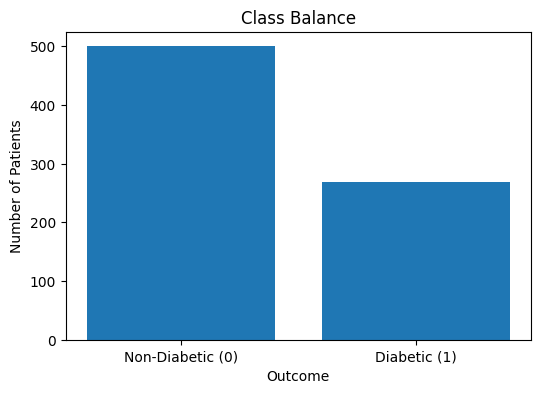

In [ ]:
count = df["Outcome"].value_counts().sort_index()
percentage = df["Outcome"].value_counts(normalize=True).sort_index() * 100

print("Class Count:")
print(count)

print("\nClass Percentage:")
print(percentage)

plt.figure(figsize=(6,4))
plt.bar(["Non-Diabetic (0)", "Diabetic (1)"], count.values)
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")
plt.title("Class Balance")
plt.show()

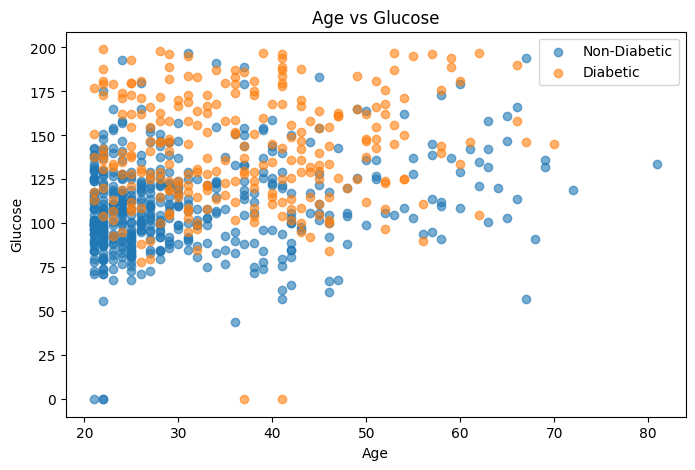

In [ ]:
plt.figure(figsize=(8,5))

for outcome in [0, 1]:
    data = df[df["Outcome"] == outcome]
    plt.scatter(
        data["Age"],
        data["Glucose"],
        label="Non-Diabetic" if outcome == 0 else "Diabetic",
        alpha=0.6
    )

plt.xlabel("Age")
plt.ylabel("Glucose")
plt.title("Age vs Glucose")
plt.legend()
plt.show()

#### **Task 3: Preprocessing and Handling Missing Values**

**Goal:** Handle anomalies and prepare numerical features for further analysis.

**Instructions:**

1. Identify the features where a value of \(0\) is physically impossible:
   \[
   \{\text{Glucose},\text{BloodPressure},\text{SkinThickness},
   \text{Insulin},\text{BMI}\}
   \]

2. Replace all invalid \(0\) values in these features with \(\mathrm{NaN}\).

3. Handle the resulting missing values by:
   - imputing them using the **mean** or **median** of the respective feature, or
   - dropping rows containing missing values to maintain numerical consistency.

In [ ]:
invalid_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

df_clean = df.copy()

for col in invalid_columns:
    df_clean[col] = df_clean[col].replace(0, np.nan)

print("Missing Values Before Imputation:")
print(df_clean.isnull().sum())

for col in invalid_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("\nMissing Values After Imputation:")
print(df_clean.isnull().sum())

Missing Values Before Imputation:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Missing Values After Imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


#### **Task 4: Stratified Train-Test Splitting**

**Goal:** Divide the data while preserving class proportions.

**Instructions:**

1. Isolate the feature matrix \(X\) and the target vector \(y\):
   \[
   X = \text{first 8 columns}
   \]
   \[
   y = \text{9th column}
   \]

2. Split the dataset into:
   \[
   \text{Training Data} = 80\%
   \]
   \[
   \text{Test Data} = 20\%
   \]

   Use **stratified sampling** to ensure that the class proportions in the target variable \(y\) are preserved in both the training and test datasets.

In [ ]:
X = df_clean.iloc[:, :-1]
y = df_clean.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

print("\nTraining Class Distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting Class Distribution:")
print(y_test.value_counts(normalize=True))

Training Data: (614, 8)
Testing Data: (154, 8)

Training Class Distribution:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Testing Class Distribution:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


#### **Task 5: Custom Bootstrap Sampling Function**

**Goal:** Implement the sampling-with-replacement mechanism.

**Instructions:**

1. Write a custom Python function \(\texttt{get\_bootstrap\_sample}(X, y)\) using NumPy's random generation tools, such as:
   \[
   \texttt{np.random.choice}
   \quad \text{or} \quad
   \texttt{np.random.randint}
   \]

2. The function must return a resampled feature matrix \(X^*\) and target vector \(y^*\) of the same size \(N\) as the training set:
   \[
   |X^*| = |y^*| = N
   \]
   
   Sampling should be performed **with replacement**, allowing duplicate rows to appear in the bootstrap sample.

3. Verify that the function works correctly by demonstrating that:
   - Some original row indices are **duplicated** in the bootstrap sample.
   - Some original row indices are **omitted**, forming the **Out-of-Bag (OOB)** samples.

In [ ]:
def get_bootstrap_sample(X, y):
    n = len(X)

    indices = np.random.choice(
        np.arange(n),
        size=n,
        replace=True
    )

    X_bootstrap = X.iloc[indices]
    y_bootstrap = y.iloc[indices]

    return X_bootstrap, y_bootstrap, indices

In [ ]:
X_boot, y_boot, indices = get_bootstrap_sample(X_train, y_train)

print("Original Training Size:", len(X_train))
print("Bootstrap Sample Size:", len(X_boot))

unique_indices = np.unique(indices)

print("Unique Samples:", len(unique_indices))
print("Duplicated Samples:", len(indices) - len(unique_indices))

oob_indices = np.setdiff1d(
    np.arange(len(X_train)),
    unique_indices
)

print("OOB Samples:", len(oob_indices))
print("OOB Indices:", oob_indices[:20])

Original Training Size: 614
Bootstrap Sample Size: 614
Unique Samples: 377
Duplicated Samples: 237
OOB Samples: 237
OOB Indices: [ 2  3  5  6 10 12 23 25 29 30 31 33 39 43 44 49 51 54 55 56]


#### **Task 6: Growing the Ensemble of Base Classifiers**

**Goal:** Programmatically train diverse base learners.

**Instructions:**

1. Initialize an empty list to store the trained models and choose the number of bootstrap iterations, for example:
   \[
   B = 50
   \]

2. Execute the following steps for \(B\) iterations:

   - Generate a unique bootstrap training dataset:
     \[
     (X^{*b}, y^{*b})
     \]
     using the bootstrap sampling function from **Task 5**.

   - Instantiate a Scikit-Learn `DecisionTreeClassifier` with:
     \[
     \texttt{max\_depth=None}
     \]
     This ensures that the decision trees are **fully grown**, resulting in high-variance base learners.

   - Fit the decision tree on the bootstrapped training subset:
     \[
     \text{Model}_b.fit(X^{*b}, y^{*b})
     \]

   - Append the trained model to the ensemble list.

3. After completing all \(B\) iterations, the ensemble should contain:
   \[
   B = 50
   \]
   independently trained decision trees.

In [ ]:
B = 50

ensemble = []

for i in range(B):
    X_boot, y_boot, indices = get_bootstrap_sample(
        X_train,
        y_train
    )

    tree = DecisionTreeClassifier(
        max_depth=None,
        random_state=42 + i
    )

    tree.fit(X_boot, y_boot)

    ensemble.append(tree)

print("Number of Decision Trees:", len(ensemble))

Number of Decision Trees: 50


#### **Task 7: Implementing Aggregation (Majority Voting) from Scratch**

**Goal:** Consolidate individual model decisions using majority voting.

**Instructions:**

1. Write a custom function:
   \[
   \texttt{custom\_bagging\_predict(ensemble, X\_test)}
   \]
   to generate the final predictions.

2. For each sample in \(X_{\text{test}}\), collect the predictions generated by all \(B\) decision trees in the ensemble:
   \[
   \hat{y}_1,\hat{y}_2,\ldots,\hat{y}_B
   \]

3. Apply a **majority voting** rule to determine the final predicted class. The class with the highest number of votes is selected:
   \[
   \hat{y} =
   \underset{c \in \{0,1\}}{\arg\max}
   \sum_{b=1}^{B} I(\hat{y}_b=c)
   \]

   where \(I(\cdot)\) is an indicator function.

4. The final prediction for each test sample must therefore be either:
   \[
   \hat{y} \in \{0,1\}
   \]

5. The function should return the final majority-voted predictions for all samples in \(X_{\text{test}}\).

In [ ]:
def custom_bagging_predict(ensemble, X_test):

    predictions = []

    for model in ensemble:
        pred = model.predict(X_test)
        predictions.append(pred)

    predictions = np.array(predictions)

    final_predictions = []

    for i in range(predictions.shape[1]):
        votes = predictions[:, i]

        counts = np.bincount(votes.astype(int))

        final_predictions.append(np.argmax(counts))

    return np.array(final_predictions)

In [ ]:
y_pred_bagging = custom_bagging_predict(
    ensemble,
    X_test
)

print("Bagging Predictions:")
print(y_pred_bagging)

Bagging Predictions:
[1 0 0 0 0 0 0 1 0 1 1 1 0 0 0 0 1 0 1 0 0 1 0 1 0 0 1 0 1 0 0 0 0 0 1 0 0
 0 1 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 1 1 1 0 1 0 1 0 0 1 0 0 1 0 0 1 0 0 0 1
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 1 0 0 0 0 0 1 0 0 0 0 0 0
 1 1 0 0 0 0 0 1 0 1 0 0 1 0 1 1 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 1 0]


#### **Task 8: Single Classifier vs. Bagging Performance Comparison**

- **Goal:** Observe the variance-reduction benefits of ensembling.

- **Instructions:**
  1. Train a standalone, single \(\texttt{DecisionTreeClassifier}\) (fully grown, no depth limit) on the original, un-resampled training data.
  2. Predict the classes for \(X_{\text{test}}\) using both the single tree and your custom Bagging classifier.
  3. Construct a **Confusion Matrix** for both models.
  4. Compute and print **Accuracy, Precision, Recall, and F1-Score** for both models, demonstrating how Bagging stabilizes results and reduces error rates.

In [ ]:
single_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

single_tree.fit(X_train, y_train)

y_pred_tree = single_tree.predict(X_test)

In [ ]:
def evaluate_model(name, y_true, y_pred):

    print("\n" + "="*50)
    print(name)
    print("="*50)

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)

    return cm

In [ ]:
cm_tree = evaluate_model(
    "Single Decision Tree",
    y_test,
    y_pred_tree
)


Single Decision Tree
Accuracy : 0.6818181818181818
Precision: 0.5531914893617021
Recall   : 0.48148148148148145
F1 Score : 0.5148514851485149

Confusion Matrix:
[[79 21]
 [28 26]]


In [ ]:
cm_bagging = evaluate_model(
    "Custom Bagging",
    y_test,
    y_pred_bagging
)


Custom Bagging
Accuracy : 0.7337662337662337
Precision: 0.6511627906976745
Recall   : 0.5185185185185185
F1 Score : 0.5773195876288659

Confusion Matrix:
[[85 15]
 [26 28]]


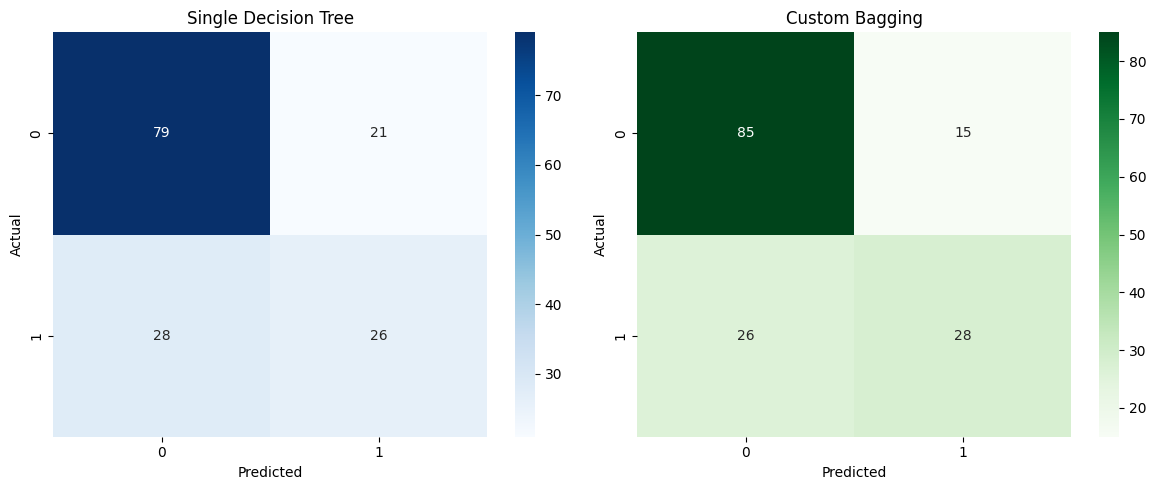

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0]
)

axes[0].set_title("Single Decision Tree")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    cm_bagging,
    annot=True,
    fmt="d",
    cmap="Greens",
    ax=axes[1]
)

axes[1].set_title("Custom Bagging")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

#### **Task 9: ROC-AUC Analysis and Curve Visualization**

- **Goal:** Measure classification performance at different thresholds.

- **Instructions:**
  1. Calculate predicted class probabilities by averaging the probability estimates (\(\texttt{predict\_proba}\)) across all \(B\) decision trees in your custom Bagging model.
  2. Plot the **Receiver Operating Characteristic (ROC) curve** for both the single decision tree and the custom Bagging model on a single chart.
  3. Compute and contrast the **Area Under the Curve (AUC)** for both configurations, noting the improvement.

In [ ]:
tree_prob = single_tree.predict_proba(X_test)[:, 1]

all_probabilities = []

for model in ensemble:
    probability = model.predict_proba(X_test)[:, 1]
    all_probabilities.append(probability)

all_probabilities = np.array(all_probabilities)

bagging_prob = np.mean(
    all_probabilities,
    axis=0
)

In [ ]:
auc_tree = roc_auc_score(
    y_test,
    tree_prob
)

auc_bagging = roc_auc_score(
    y_test,
    bagging_prob
)

print("Single Decision Tree AUC :", auc_tree)
print("Custom Bagging AUC       :", auc_bagging)

Single Decision Tree AUC : 0.6357407407407407
Custom Bagging AUC       : 0.8014814814814815


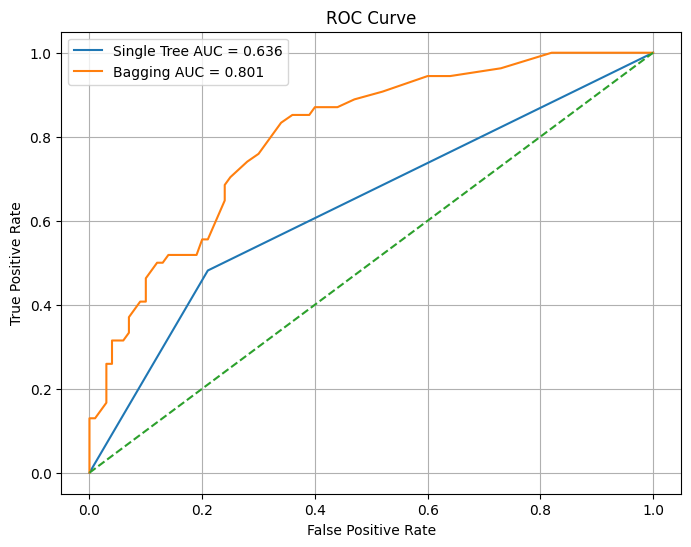

In [ ]:
fpr_tree, tpr_tree, _ = roc_curve(
    y_test,
    tree_prob
)

fpr_bagging, tpr_bagging, _ = roc_curve(
    y_test,
    bagging_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f"Single Tree AUC = {auc_tree:.3f}"
)

plt.plot(
    fpr_bagging,
    tpr_bagging,
    label=f"Bagging AUC = {auc_bagging:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

#### **Task 10: Validation against Scikit-Learn's BaggingClassifier**

- **Goal:** Verify custom code correctness.

- **Instructions:**
  1. Instantiate Scikit-Learn's built-in \(\texttt{BaggingClassifier}\) using \(\texttt{DecisionTreeClassifier(max\_depth=None)}\) as the base estimator and \(\texttt{n\_estimators=50}\).
  2. Fit the classifier on the training set and evaluate it on the test set.
  3. Compare the resulting test accuracy and confusion matrix against your custom implementation from **Task 7** and **Task 8** to validate your custom bootstrap and aggregation logic.

In [ ]:
sklearn_bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=None),
    n_estimators=50,
    random_state=42
)

sklearn_bagging.fit(X_train, y_train)

y_pred_sklearn = sklearn_bagging.predict(X_test)

print("Scikit-Learn Bagging Accuracy:")
print(accuracy_score(y_test, y_pred_sklearn))

print("\nScikit-Learn Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_sklearn))

Scikit-Learn Bagging Accuracy:
0.7337662337662337

Scikit-Learn Confusion Matrix:
[[85 15]
 [26 28]]


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Single Decision Tree",
        "Custom Bagging",
        "Scikit-Learn Bagging"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_bagging),
        accuracy_score(y_test, y_pred_sklearn)
    ],
    "Precision": [
        precision_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_bagging),
        precision_score(y_test, y_pred_sklearn)
    ],
    "Recall": [
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_bagging),
        recall_score(y_test, y_pred_sklearn)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_bagging),
        f1_score(y_test, y_pred_sklearn)
    ],
    "AUC": [
        auc_tree,
        auc_bagging,
        roc_auc_score(
            y_test,
            sklearn_bagging.predict_proba(X_test)[:, 1]
        )
    ]
})

display(results)

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Single Decision Tree,0.681818,0.553191,0.481481,0.514851,0.635741
1,Custom Bagging,0.733766,0.651163,0.518519,0.577320,0.801481
2,Scikit-Learn Bagging,0.733766,0.651163,0.518519,0.577320,0.799907


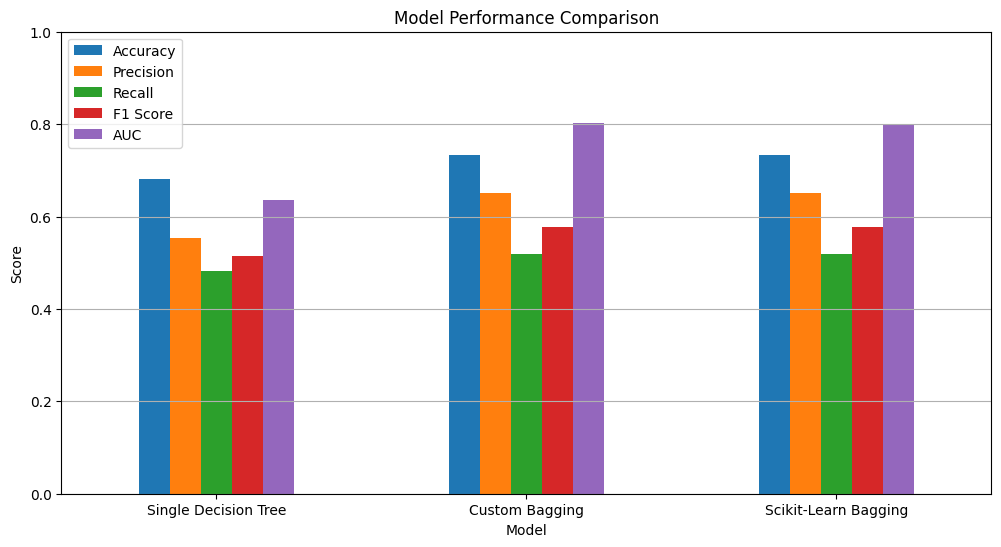

In [ ]:
results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score", "AUC"]
].plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

### **Conclusion and Interpretation**

Students should summarize their findings by answering the following key questions:

1. **Variance and Stability:** How does the test accuracy of the Bagging ensemble compare to the single decision tree? Why does Bagging provide more consistent performance across different train-test splits?

2. **Wisdom of Crowds:** How does random resampling with replacement (bootstrapping) foster model diversity, and how does the consensus voting rule translate to a "Wisdom of Crowds" effect?

3. **Clinical Interpretation:** In predicting diabetes, why are False Negatives (predicting non-diabetic for a diabetic patient) especially costly, and how does Bagging's Recall metric help minimize this risk compared to a single decision tree?